## THIS NOTEBOOK DOES EXPLORATORY DATA ANALYSIS (eda) OF THE DATASET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [3]:
df = pd.read_csv('../data/raw/Customertravel.csv')
df.head()
#1 -> churned, 0 -> not churned

,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,No,Middle Income,6,No,Yes,0
1,34,Yes,Low Income,5,Yes,No,1
2,37,No,Middle Income,3,Yes,No,0
3,30,No,Middle Income,2,No,No,0
4,30,No,Low Income,1,No,No,0


In [4]:
print(df.shape)          
print(df.dtypes)                
print(df.nunique())             
df.describe()        

(954, 7)
Age                            int64
FrequentFlyer                 object
AnnualIncomeClass             object
ServicesOpted                  int64
AccountSyncedToSocialMedia    object
BookedHotelOrNot              object
Target                         int64
dtype: object
Age                           11
FrequentFlyer                  3
AnnualIncomeClass              3
ServicesOpted                  6
AccountSyncedToSocialMedia     2
BookedHotelOrNot               2
Target                         2
dtype: int64


,Age,ServicesOpted,Target
count,954.000000,954.000000,954.000000
mean,32.109015,2.437107,0.234801
std,3.337388,1.606233,0.424097
min,27.000000,1.000000,0.000000
25%,30.000000,1.000000,0.000000
50%,31.000000,2.000000,0.000000
75%,35.000000,4.000000,0.000000
max,38.000000,6.000000,1.000000


## Observations: Initial EDA
- Dataset has `954 rows` and `7 columns` (6 features + 1 target) <br>
- 4 features are **categorical**, 2 are **numerical** <br>
- The categories will be encoded during preprocessing

In [5]:
churn_counts = df['Target'].value_counts()
churn_counts

Target
0    730
1    224
Name: count, dtype: int64

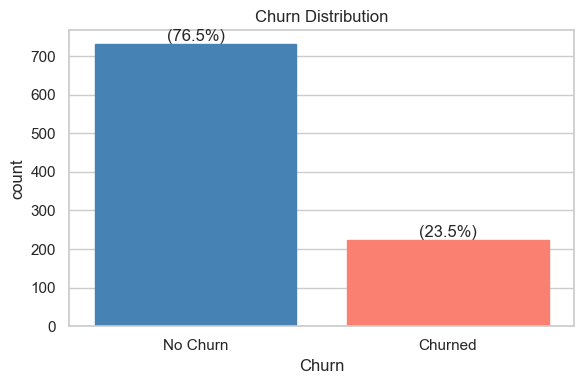

In [6]:
df['Churn'] =df['Target'].map({0: 'No Churn', 1: 'Churned'})
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Churn', data=df, ax=ax)
ax.set_title('Churn Distribution')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'({height/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom')
bars = ax.patches
colors = ['steelblue', 'salmon']

for bar, color in zip(bars, colors):
    bar.set_color(color)
plt.tight_layout()
plt.savefig('../outputs/figures/churn_distribution.png', dpi=150)
plt.show()

## Obeservations: Churn Distribution
**Churn**: 23.5% (224) <br>
**No churn**: 76.5% (730) <br>
Thus this data is highly imbalanced. This can affect the model training <br>
This needs to be fixed using SMOTE or Cross Validation 

In [7]:
null_df = pd.DataFrame({
    'Missing Count': df.isnull().sum()
})
null_df

,Missing Count
Age,0
FrequentFlyer,0
AnnualIncomeClass,0
ServicesOpted,0
AccountSyncedToSocialMedia,0
BookedHotelOrNot,0
Target,0
Churn,0


**NO NULL VALUES**

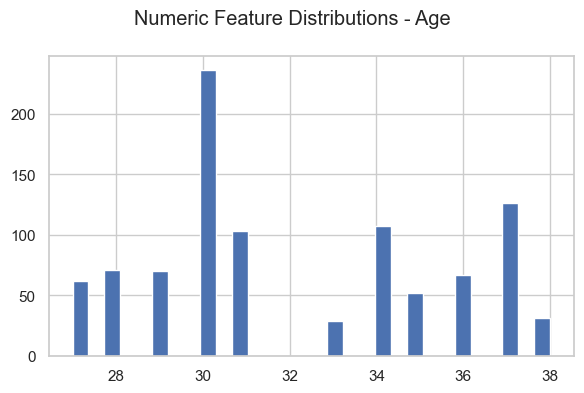

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Target') 

df['Age'].hist(bins=30, figsize=(6, 4))
plt.suptitle('Numeric Feature Distributions - Age')
plt.tight_layout()
plt.savefig('../outputs/figures/numeric_distributions(age).png', dpi=150)
plt.show()

## Obesrvations : Numerical Features (Age)
The **Age** distribution bunches up around `30`. <br> The dataset can be synthetic, or might have less unique datapoints. <br> Not very much evenly distributed.

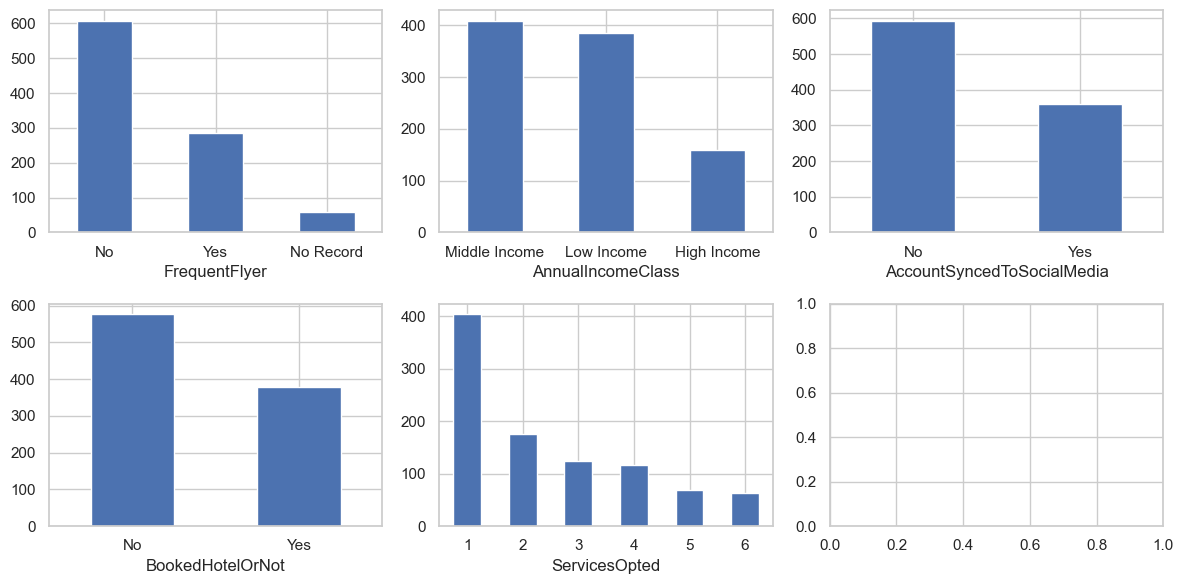

In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['Churn']]
cat_cols.append('ServicesOpted') #considering this as categorical for EDA because it has less unique values

fig, axes = plt.subplots(nrows=len(cat_cols)//3+1, ncols=3, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/categorical_distributions.png', dpi=150)
plt.show()

## Observations: Categorical Feature Distributions

**FrequentFlyer:** Majority of customers are non-frequent flyers (No ~63%).<br>
**AnnualIncomeClass:** Balanced majorly<br>
**AccountSyncedToSocialMedia:** Most customers have not synced. Can display less engagement (very slight imbalance)<br>
**BookedHotelOrNot:** Almost balanced<br>
**ServicesOpted:** Heavily right-skewed — most customers opt for only 1 service

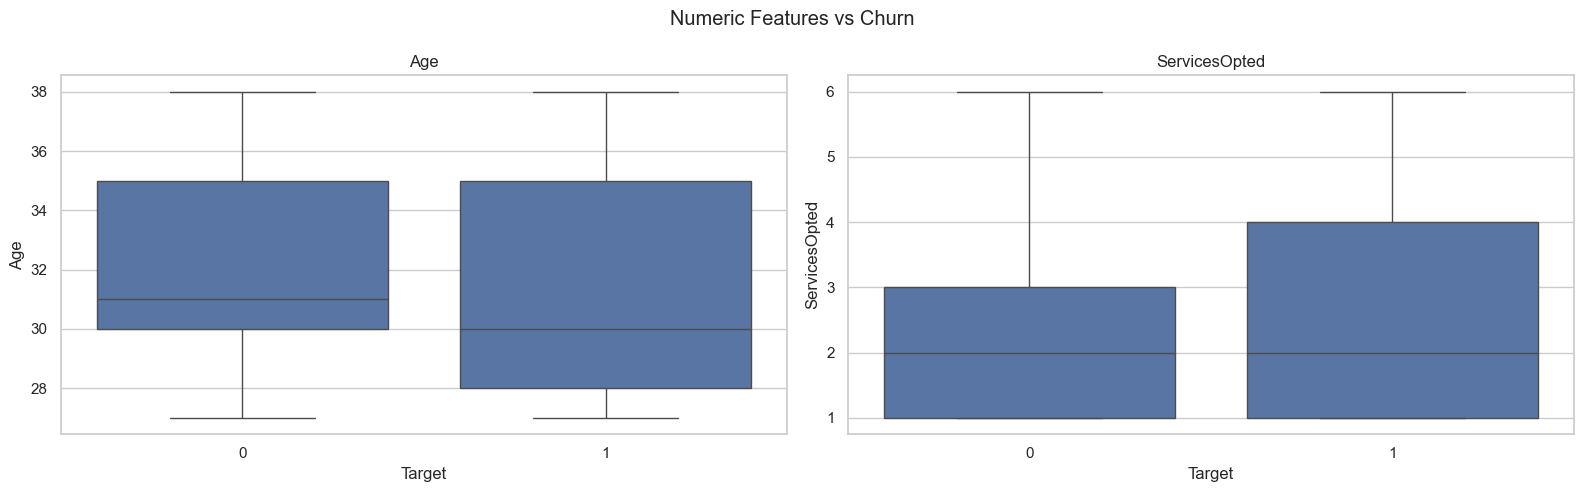

In [10]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Target', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle('Numeric Features vs Churn')
plt.tight_layout()
plt.savefig('../outputs/figures/numeric_vs_churn.png', dpi=150)
plt.show()

## Observation: Numeric Features vs Churn
**Age**: The distribution of churn and no churn based on Age is very identical, indicating that it might not be a major point that can be used for training and prediction <br>
**ServicesOpted**: The distribution of churn and no churn based on services opted indicated that people who opt for more services are more likely to churn ? But since the plot expands over the whole distribution, it also cannot be a major point for training and prediction

In [13]:
cat_cols.remove('ServicesOpted')

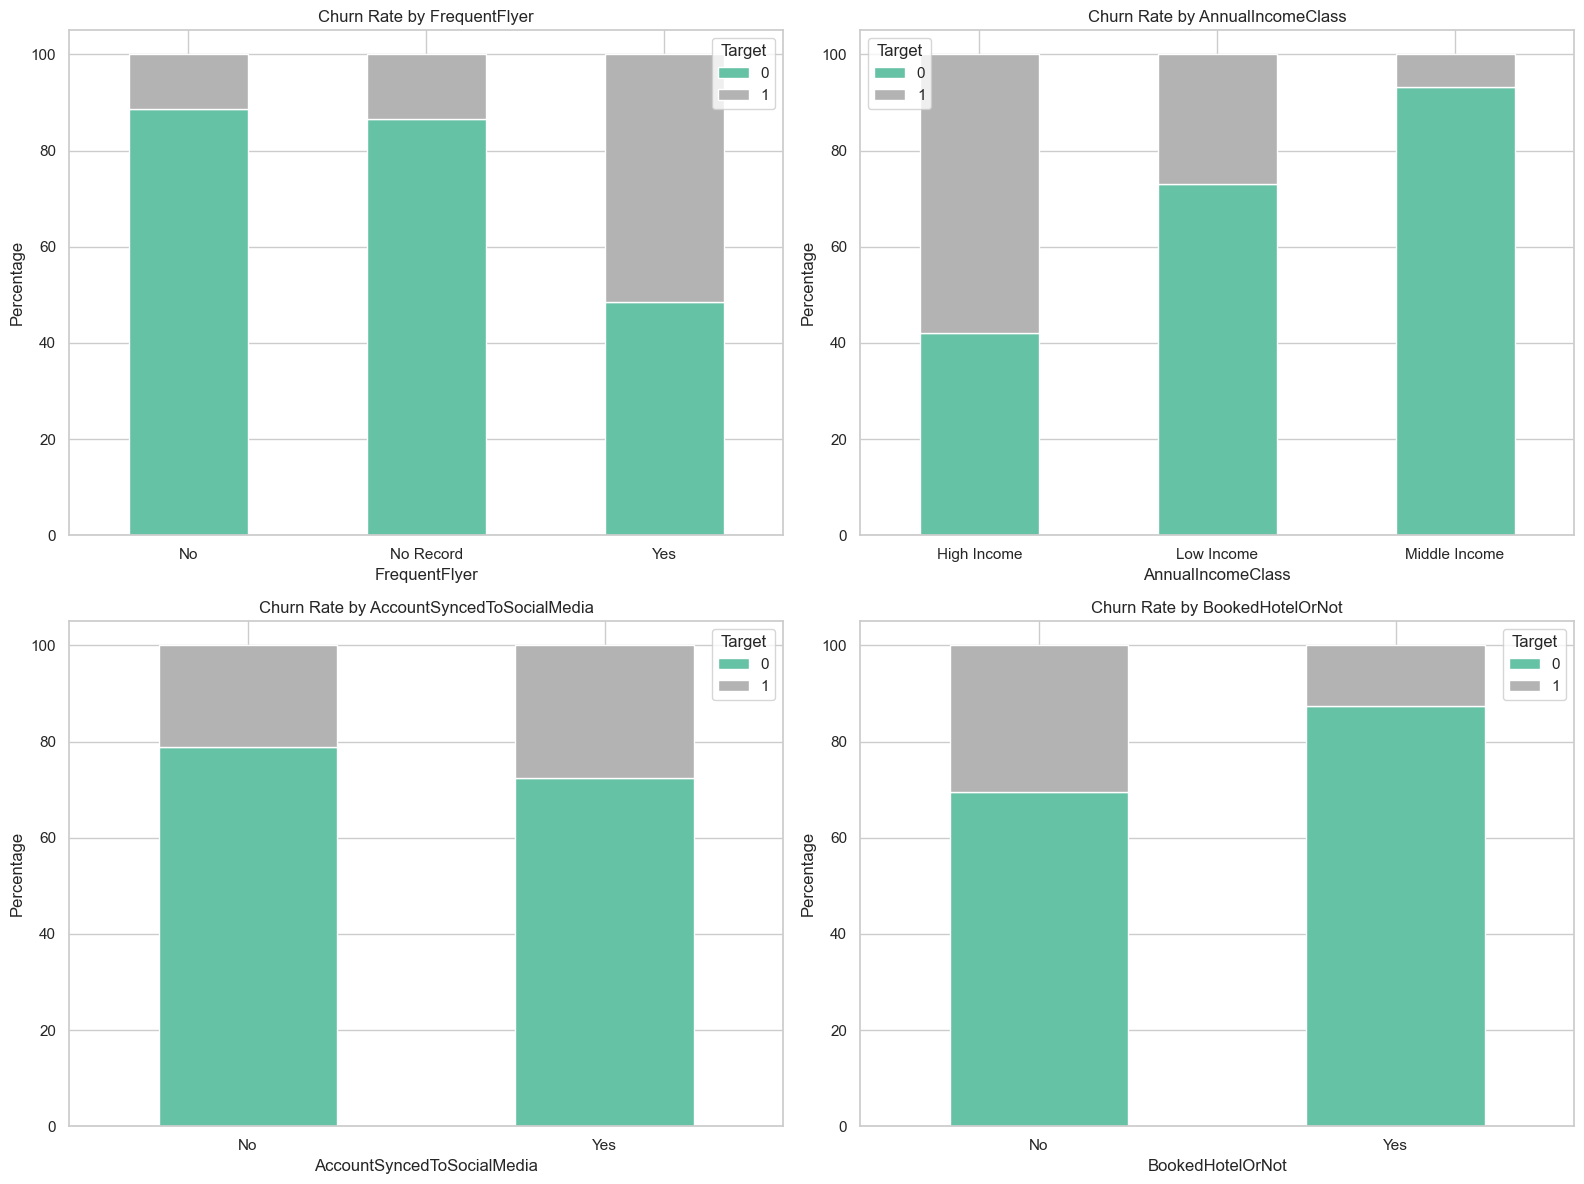

In [15]:
fig, axes = plt.subplots(nrows=len(cat_cols)//3 + 1, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Target'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Percentage')
    axes[i].tick_params(rotation=0)

plt.tight_layout()
plt.savefig(f'../outputs/figures/categorical_vs_churn.png', dpi=150)
plt.show()

## Observation: Categorical Features vs Churn
**FrequentFlyer**: Almost 50% of people who are frequent flyers are also Churners, whereas upto 90% of infrequent flyers do not churn. This can be a major point for prediction <br>
**AnnualIncomeClass**: As we can see, upto 90%+ middle income travellers do not churn, whereas upto 60% of high incomers churn. Can also consider this point. <br>
**AccountSyncedToSocialMedia**: A weak signal datapoint, as both distributions are similar. <br>
**BookedHotelOrNot**: A moderate signal datapoint -> when complex entries need to be predicted as we can see in both cases, more than 50% people do not churn, thus showing less of a direct relation.